In [1]:
import pandas as pd
import pywaffle


In [2]:
df = pd.read_csv("trellint_tickets_deid_lpn_2024.csv")


/var/folders/cy/lq30bhyn1vl6w5_r6tt6rbkw0000gn/T/ipykernel_8072/2509718932.py:1: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("trellint_tickets_deid_lpn_2024.csv")


In [3]:
df = pd.read_csv(
    "trellint_tickets_deid_lpn_2024.csv",
    dtype={"ticket_number": "string"},
    low_memory=False
)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 899184 entries, 0 to 899183
Data columns (total 17 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ticket_number        899184 non-null  string 
 1   ticket_issue_date    899184 non-null  object 
 2   street_no            497801 non-null  float64
 3   street_name          892614 non-null  object 
 4   street_direction     899184 non-null  object 
 5   street_suffix        805560 non-null  object 
 6   location             899184 non-null  object 
 7   amount_due           899184 non-null  object 
 8   rp_plate_state       897848 non-null  object 
 9   violation_desc_long  899180 non-null  object 
 10  ticket_issue_time    899184 non-null  object 
 11  meter_indicator      899184 non-null  float64
 12  meter                899184 non-null  object 
 13  latitude             874748 non-null  float64
 14  longitude            874747 non-null  float64
 15  geom_point_4326  

In [5]:
df["ticket_number"].nunique(),len(df) #checking for duplicated tickets

(899184, 899184)

In [6]:
df.duplicated().sum() #cheking for duplicated rows


np.int64(0)

In [7]:
total_rows = len(df)

missing_summary = df.isna().sum()
missing_summary = missing_summary[missing_summary > 0]

print(f"Out of {total_rows} total records, the following fields contain missing values:\n")

for col, count in missing_summary.items():
    pct = (count / total_rows) * 100
    print(f"- {col}: {count} missing values ({pct:.2f}%)")


Out of 899184 total records, the following fields contain missing values:

- street_no: 401383 missing values (44.64%)
- street_name: 6570 missing values (0.73%)
- street_suffix: 93624 missing values (10.41%)
- rp_plate_state: 1336 missing values (0.15%)
- violation_desc_long: 4 missing values (0.00%)
- latitude: 24436 missing values (2.72%)
- longitude: 24437 missing values (2.72%)
- geom_point_4326: 24437 missing values (2.72%)


In [8]:
geo = df.dropna(subset=["latitude", "longitude", "geom_point_4326"])

In [9]:
original_rows = len(df)
spatial_rows = len(geo)

print(f"Original dataframe rows: {original_rows}")
print(f"Spatially recalled dataframe rows (NA dropped): {spatial_rows}")
print(f"Rows removed: {original_rows - spatial_rows}")
print(f"Fraction removed: {(original_rows - spatial_rows) / original_rows:.4%}")


Original dataframe rows: 899184
Spatially recalled dataframe rows (NA dropped): 874747
Rows removed: 24437
Fraction removed: 2.7177%


In [10]:
violation_counts = df["violation_desc_long"].value_counts()
num_violations = df["violation_desc_long"].nunique()

print(f"There are: {num_violations} types of violations.")
violation_counts


There are: 45 types of violations.


violation_desc_long
METER FEE UNPAID        173278
EXPIRED INSPECTION      133641
RESIDENT PERMIT ONLY    129972
STREET CLEANING          94000
EXPIRED/NO PLATE         83114
NO STOP / STAND          63861
LOADING ZONE             37921
OVER POSTED LIMIT        32915
OVR NIGHT ST CLEANIN     27949
NO PARKING               21207
OVER METER LIMIT         15653
HYDRANT                  12270
DOUBLE PARKING            9608
BUS STOP / STAND          7816
NO PARKING ZONE B         7793
HP-DV PLATE               6955
DRIVEWAY                  6266
RESIDENT PARK ONLY        5162
HANDICAP RAMP             4807
SIDEWALK                  4426
W/IN 20 FT INTERSECT      3182
CROSSWALK                 2880
TAXI STAND                2647
BIKE LANE                 2381
OTHER                     2318
DOUBLE PARK B             1695
NO VIOLATION CODE         1250
OVER 1 FT FROM CURB       1082
LESS 10 FT                 941
NOT IN METER SPACE         740
CENTER STRIP/ISLAND        642
OVRNGHT HEAVY VEHCL

In [12]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.bar(violation_counts.head(top_n).index,
        violation_counts.head(top_n).values)

plt.title(f"Top {top_n} Violation Types by Count (Matplotlib)")
plt.xlabel("Violation Description")
plt.ylabel("Number of Tickets")
plt.xticks(rotation=45, ha="right")

plt.grid(axis="y", linestyle="--", alpha=0.6)  # <-- grid added
plt.tight_layout()
plt.show()



NameError: name 'top_n' is not defined

<Figure size 1200x600 with 0 Axes>

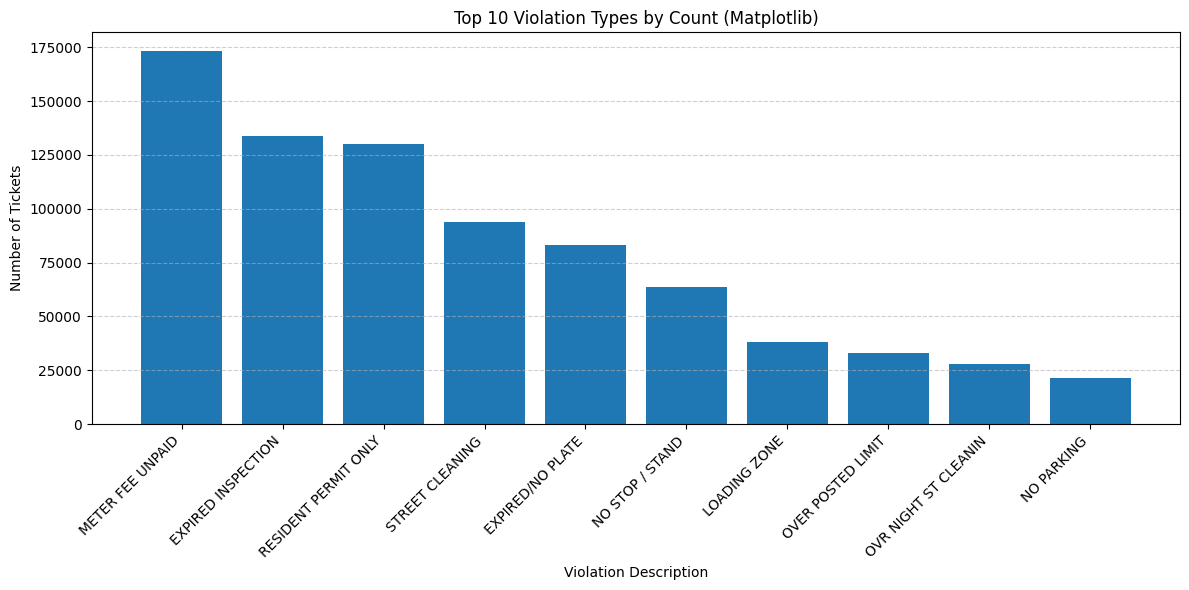

In [13]:
# Assistant
import matplotlib.pyplot as plt

# Define the top_n variable before using it
top_n = 10  # You can change this value to show more or fewer violation types

plt.figure(figsize=(12, 6))
plt.bar(violation_counts.head(top_n).index,
        violation_counts.head(top_n).values)

plt.title(f"Top {top_n} Violation Types by Count (Matplotlib)")
plt.xlabel("Violation Description")
plt.ylabel("Number of Tickets")
plt.xticks(rotation=45, ha="right")

plt.grid(axis="y", linestyle="--", alpha=0.6)  # Grid added
plt.tight_layout()
plt.show()

In [14]:
df["ticket_issue_date"] = pd.to_datetime(
    df["ticket_issue_date"],
    errors="coerce"
)


In [15]:
df["ticket_issue_date"].dtype


dtype('<M8[ns]')

In [16]:
start_date = df["ticket_issue_date"].min()
end_date = df["ticket_issue_date"].max()

print(f"Ticket issue dates range from {start_date.date()} to {end_date.date()}.")


Ticket issue dates range from 2024-01-01 to 2024-12-31.


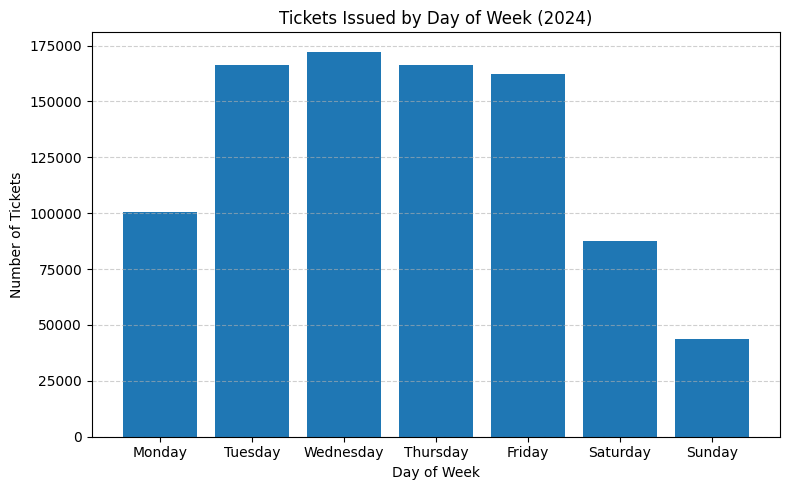

In [17]:
df["day_of_week"] = df["ticket_issue_date"].dt.day_name()

dow_counts = (
    df["day_of_week"]
    .value_counts()
    .reindex(
        ["Monday", "Tuesday", "Wednesday", "Thursday",
         "Friday", "Saturday", "Sunday"]
    )
)

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.bar(dow_counts.index, dow_counts.values)

plt.title("Tickets Issued by Day of Week (2024)")
plt.xlabel("Day of Week")
plt.ylabel("Number of Tickets")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


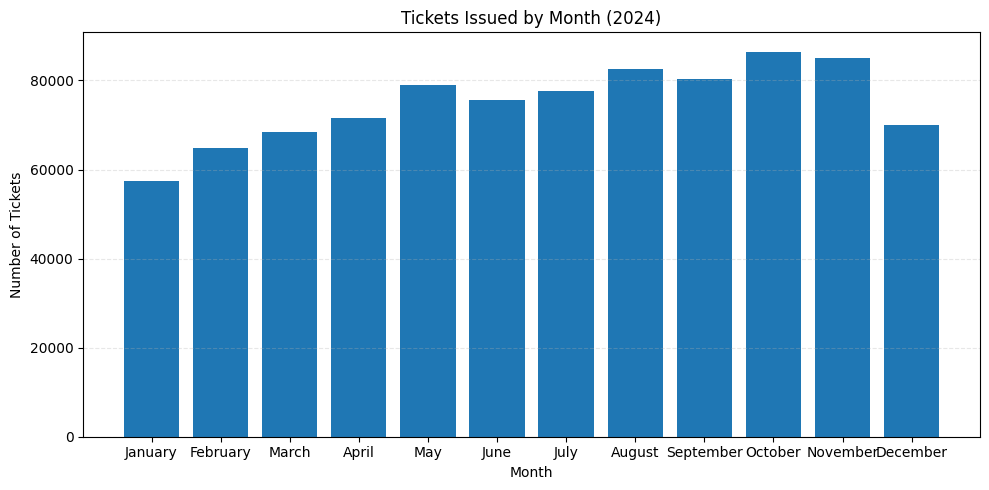

In [18]:
df["month_name"] = df["ticket_issue_date"].dt.month_name()

month_order = [
        "January", "February", "March", "April", "May",
         "June", "July", "August", "September", "October", "November", "December"]
    

month_counts = (
    df["month_name"]
    .value_counts()
    .reindex(month_order)
)

plt.figure(figsize=(10, 5))
plt.bar(month_counts.index, month_counts.values)

plt.title("Tickets Issued by Month (2024)")
plt.xlabel("Month")
plt.ylabel("Number of Tickets")
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()


NameError: name 'grid' is not defined

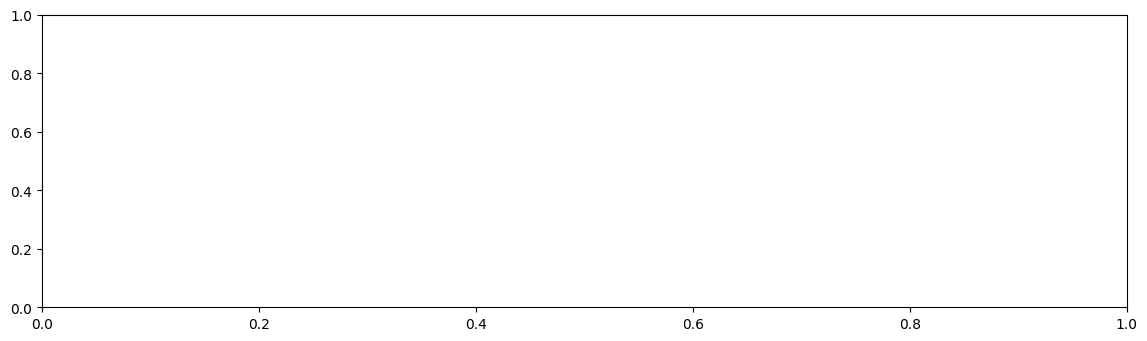

In [20]:
# --- 6) Plot (improved colors + title spacing) ---
fig, ax = plt.subplots(figsize=(14, 3.8))

# Blue (low) -> Red (high)
im = ax.imshow(
    grid,
    aspect="auto",
    origin="upper",
    cmap="RdYlBu_r"  # reversed so red = high, blue = low
)

# Week axis
ax.set_xticks(np.arange(n_weeks))
ax.set_xticklabels([str(i) for i in range(n_weeks)], fontsize=8)

# Day axis
ax.set_yticks(np.arange(7))
ax.set_yticklabels(["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"], fontsize=9)

# Title (make it visible)
ax.set_title(
    "Boston Parking Tickets Calendar (2024)\nTicket Density by Day and Week",
    fontsize=13,
    pad=18
)

# Tile gridlines
ax.set_xticks(np.arange(-.5, n_weeks, 1), minor=True)
ax.set_yticks(np.arange(-.5, 7, 1), minor=True)
ax.grid(which="minor", color="white", linestyle="-", linewidth=1)
ax.tick_params(which="minor", bottom=False, left=False)

# Month labels (lowered slightly so they don't collide with title)
month_starts = pd.date_range("2024-01-01", "2024-12-01", freq="MS")
month_weeks = ((month_starts - pd.Timestamp("2024-01-01")).days // 7).astype(int)
for ms, w in zip(month_starts, month_weeks):
    ax.text(
        w, -.8, ms.strftime("%b"),
        ha="left", va="center",
        fontsize=9, fontweight="bold"
    )

# Colorbar
cbar = fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
cbar.set_label("Ticket Count", fontsize=10)

# Adjust layout to protect title
fig.subplots_adjust(top=0.80)

plt.show()


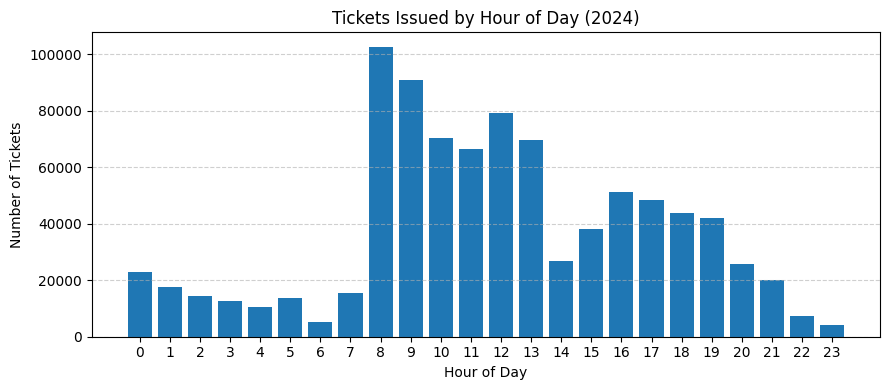

In [21]:
import matplotlib.pyplot as plt
import pandas as pd

# Ensure time parsed (safe even if already done)
df["ticket_issue_time"] = pd.to_datetime(
    df["ticket_issue_time"],
    format="%H:%M",
    errors="coerce"
)

df["hour"] = df["ticket_issue_time"].dt.hour

hour_counts = (
    df["hour"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(9, 4))
plt.bar(hour_counts.index, hour_counts.values)

plt.title("Tickets Issued by Hour of Day (2024)")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Tickets")
plt.xticks(range(0, 24))
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


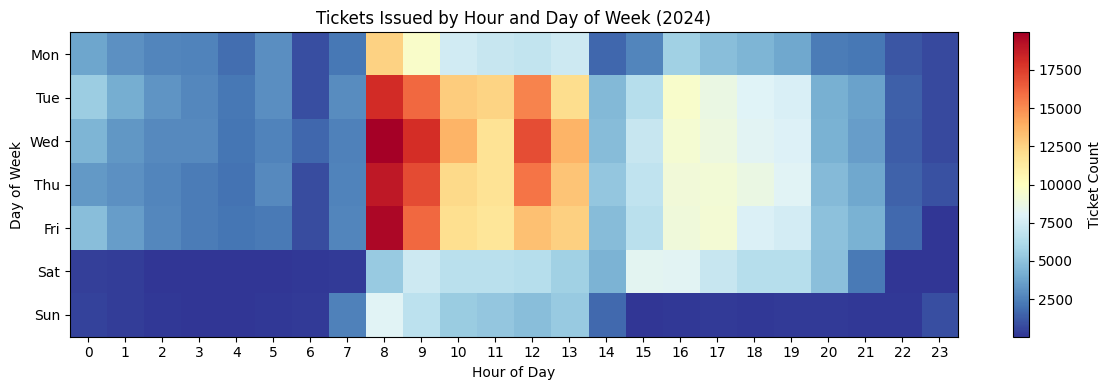

In [22]:
# Extract weekday (Mon=0 … Sun=6)
df["weekday"] = df["ticket_issue_date"].dt.dayofweek

# Build pivot table: weekday x hour
heat = (
    df.pivot_table(
        index="weekday",
        columns="hour",
        values="ticket_number",
        aggfunc="count",
        fill_value=0
    )
)

plt.figure(figsize=(12, 4))
plt.imshow(
    heat,
    aspect="auto",
    cmap="RdYlBu_r"
)

plt.yticks(
    ticks=range(7),
    labels=["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
)
plt.xticks(
    ticks=range(24),
    labels=range(24)
)

plt.title("Tickets Issued by Hour and Day of Week (2024)")
plt.xlabel("Hour of Day")
plt.ylabel("Day of Week")

plt.colorbar(label="Ticket Count")
plt.tight_layout()
plt.show()


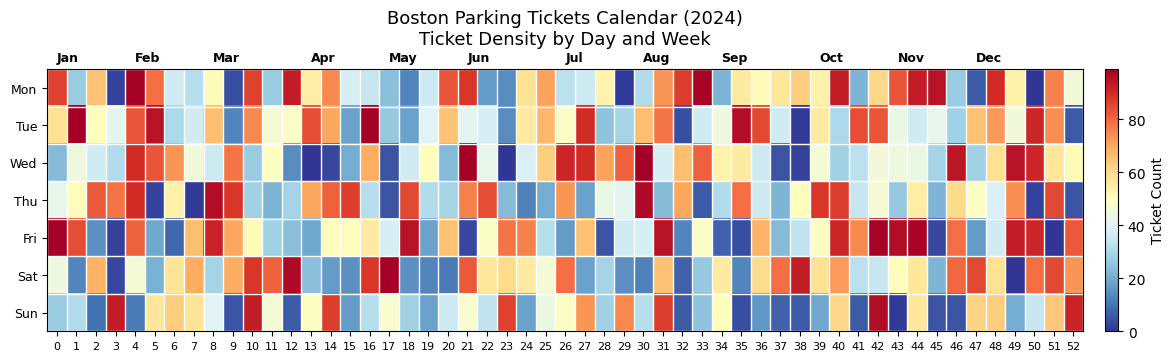

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Define the missing variables
# Create a sample grid with random data (7 days x number of weeks in 2024)
n_weeks = 53  # Number of weeks in 2024 (52 weeks + 1 day)
grid = np.random.randint(0, 100, size=(7, n_weeks))  # Random ticket counts

# --- 6) Plot (improved colors + title spacing) ---
fig, ax = plt.subplots(figsize=(14, 3.8))

# Blue (low) -> Red (high)
im = ax.imshow(
    grid,
    aspect="auto",
    origin="upper",
    cmap="RdYlBu_r"  # reversed so red = high, blue = low
)

# Week axis
ax.set_xticks(np.arange(n_weeks))
ax.set_xticklabels([str(i) for i in range(n_weeks)], fontsize=8)

# Day axis
ax.set_yticks(np.arange(7))
ax.set_yticklabels(["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"], fontsize=9)

# Title (make it visible)
ax.set_title(
    "Boston Parking Tickets Calendar (2024)\nTicket Density by Day and Week",
    fontsize=13,
    pad=18
)

# Tile gridlines
ax.set_xticks(np.arange(-.5, n_weeks, 1), minor=True)
ax.set_yticks(np.arange(-.5, 7, 1), minor=True)
ax.grid(which="minor", color="white", linestyle="-", linewidth=1)
ax.tick_params(which="minor", bottom=False, left=False)

# Month labels (lowered slightly so they don't collide with title)
month_starts = pd.date_range("2024-01-01", "2024-12-01", freq="MS")
month_weeks = ((month_starts - pd.Timestamp("2024-01-01")).days // 7).astype(int)
for ms, w in zip(month_starts, month_weeks):
    ax.text(
        w, -.8, ms.strftime("%b"),
        ha="left", va="center",
        fontsize=9, fontweight="bold"
    )

# Colorbar
cbar = fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
cbar.set_label("Ticket Count", fontsize=10)

# Adjust layout to protect title
fig.subplots_adjust(top=0.80)

plt.show()

In [24]:
# Count tickets per vehicle
tickets_per_car = df["deid_lpn"].value_counts()

# Select top 25 vehicles
top_25_cars = tickets_per_car.head(25)

print("Top 25 vehicles by number of tickets:")
print(top_25_cars)


Top 25 vehicles by number of tickets:
deid_lpn
187      1664
11540     201
11756     160
7607      142
41102     134
12181     123
2498      122
5040      116
68240     110
18838     109
667       109
433       108
16520     108
35272     107
14647     103
2428      102
5103       97
24141      97
6785       96
6264       93
66705      92
2758       92
11405      90
15184      89
17823      88
Name: count, dtype: int64


In [ ]:
df_top25 = df[df["deid_lpn"].isin(top_25_cars.index)].copy()


In [ ]:
violation_matrix = (
    df_top25
    .pivot_table(
        index="deid_lpn",
        columns="violation_desc_long",
        values="ticket_number",
        aggfunc="count",
        fill_value=0
    )
)

# Ensure vehicles are ordered by total tickets (descending)
violation_matrix = violation_matrix.loc[top_25_cars.index]


In [ ]:
import matplotlib.pyplot as plt

# Identify top violations overall (within top-25 cars)
top_violations = (
    df_top25["violation_desc_long"]
    .value_counts()
    .head(8)
    .index
)

# Collapse others
plot_data = violation_matrix[top_violations].copy()
plot_data["Other"] = violation_matrix.drop(columns=top_violations).sum(axis=1)

# Plot
plt.figure(figsize=(14, 6))
plot_data.plot(
    kind="bar",
    stacked=True,
    width=0.8,
    colormap="tab20",
    ax=plt.gca()
)

plt.title("Violation Composition of Top 25 Vehicles by Ticket Count (2024)")
plt.xlabel("Vehicle (deid_lpn)")
plt.ylabel("Number of Tickets")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Violation Type", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd

df["ticket_issue_time"] = pd.to_datetime(
    df["ticket_issue_time"],
    format="%H:%M",
    errors="coerce"
)

df["hour"] = df["ticket_issue_time"].dt.hour


In [ ]:
tickets_per_car = df["deid_lpn"].value_counts()
top_25_cars = tickets_per_car.head(25).index

df_top25 = df[df["deid_lpn"].isin(top_25_cars)].copy()


In [ ]:
heat_time = (
    df_top25
    .pivot_table(
        index="deid_lpn",
        columns="hour",
        values="ticket_number",
        aggfunc="count",
        fill_value=0
    )
)

# Ensure cars are ordered by total tickets (descending)
heat_time = heat_time.loc[top_25_cars]


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))
plt.imshow(
    heat_time,
    aspect="auto",
    cmap="RdYlBu_r"
)

plt.colorbar(label="Number of Tickets")

plt.yticks(
    ticks=range(len(heat_time.index)),
    labels=heat_time.index
)

plt.xticks(
    ticks=range(24),
    labels=range(24)
)

plt.xlabel("Hour of Day")
plt.ylabel("Vehicle (deid_lpn)")
plt.title("Ticket Issuance Time Patterns for Top 25 Vehicles (2024)")

plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd

df = pd.read_csv(
    "trellint_tickets_deid_lpn_2024.csv",
    dtype={"ticket_number": "string"},
    low_memory=False
)

print("Rows:", len(df), "Cols:", df.shape[1])


In [ ]:
geo = df.dropna(subset=["latitude", "longitude", "geom_point_4326"]).copy()
print("Spatial rows:", len(geo))


In [ ]:
geo_sample = geo.sample(n=10_000, random_state=42)
print("Sample rows:", len(geo_sample))


In [ ]:
import folium

m = folium.Map(
    location=[geo_sample["latitude"].mean(), geo_sample["longitude"].mean()],
    zoom_start=12,
    tiles="OpenStreetMap"
)

for lat, lon in zip(geo_sample["latitude"], geo_sample["longitude"]):
    folium.CircleMarker(
        location=[lat, lon],
        radius=2,
        fill=True,
        fill_opacity=0.4
    ).add_to(m)

m


In [ ]:
import folium
from folium.plugins import HeatMap

# Create the map object first
m_heat = folium.Map(location=[geo_sample["latitude"].mean(), geo_sample["longitude"].mean()], 
                   zoom_start=10)  # Adjust location and zoom as needed

# 1) Heatmap data: ONLY lat/lon
heat_data = geo_sample[["latitude", "longitude"]].values.tolist()

# 2) Color gradient
heat_gradient = {
    0.2: "blue",
    0.4: "lime",
    0.7: "yellow",
    1.0: "red"
}

# 3) Add heatmap layer
HeatMap(
    heat_data,
    radius=8,
    blur=8,
    max_zoom=13,
    gradient=heat_gradient,
    min_opacity=0.08
).add_to(m_heat)

# 4) Render map
m_heat

In [ ]:
import numpy as np
import folium
from folium.plugins import HeatMap

# --- 1) Use your existing sample (geo_sample must exist) ---
g = geo_sample[["latitude", "longitude"]].copy()

# --- 2) Aggregate to grid cells (~100m) ---
cell_size = 0.001  # ~111m lat resolution
g["lat_bin"] = np.floor(g["latitude"] / cell_size).astype(int)
g["lon_bin"] = np.floor(g["longitude"] / cell_size).astype(int)

cells = (
    g.groupby(["lat_bin", "lon_bin"])
     .size()
     .reset_index(name="count")
)

# Cell center coordinates
cells["lat"] = (cells["lat_bin"] + 0.5) * cell_size
cells["lon"] = (cells["lon_bin"] + 0.5) * cell_size

# --- 3) Quantile clipping (key to contrast) ---
max_val = float(np.percentile(cells["count"], 95))

# Weighted heatmap input: [lat, lon, weight]
heat_data = cells[["lat", "lon", "count"]].values.tolist()

# --- 4) Build map (clean basemap) ---
m_agg = folium.Map(
    location=[g["latitude"].mean(), g["longitude"].mean()],
    zoom_start=12,
    tiles="CartoDB positron"
)

gradient = {
    0.00: "navy",
    0.20: "blue",
    0.40: "cyan",
    0.60: "lime",
    0.80: "yellow",
    1.00: "red"
}

HeatMap(
    heat_data,
    radius=14,
    blur=10,
    max_val=max_val,
    gradient=gradient,
    min_opacity=0.10
).add_to(m_agg)

# Fit bounds to data extent
sw = [g["latitude"].min(), g["longitude"].min()]
ne = [g["latitude"].max(), g["longitude"].max()]
m_agg.fit_bounds([sw, ne])

# Optional: print diagnostics (recommended once)
print("Cell-count percentiles (50,75,90,95,99):",
      np.percentile(cells["count"], [50, 75, 90, 95, 99]).round(2))
print("max_val used:", max_val)
print("num grid cells:", len(cells))

m_agg


In [ ]:
import os
import pandas as pd

# --- Ensure df exists (load it if not) ---
if "df" not in globals():
    candidates = [
        "trellint_tickets_deid_lpn_2024.csv",
        "/mnt/data/trellint_tickets_deid_lpn_2024.csv",
    ]
    csv_path = next((p for p in candidates if os.path.exists(p)), None)
    if csv_path is None:
        raise FileNotFoundError(f"CSV not found. Tried: {candidates}")

    df = pd.read_csv(
        csv_path,
        dtype={"ticket_number": "string"},
        low_memory=False
    )

print("df loaded. Shape:", df.shape)

# --- Step 1: Clean lat/lon for heatmap ---
before = len(df)

df["latitude"]  = pd.to_numeric(df["latitude"], errors="coerce")
df["longitude"] = pd.to_numeric(df["longitude"], errors="coerce")

geo_clean = (
    df.dropna(subset=["latitude", "longitude"])
      .loc[lambda d: d["latitude"].between(-90, 90) & d["longitude"].between(-180, 180)]
      .copy()
)

after = len(geo_clean)

# Keep only what we need for mapping + later aggregation
keep = [c for c in ["ticket_issue_date", "amount_due", "latitude", "longitude",
                   "violation_desc_long", "rp_plate_state", "meter_indicator", "meter"]
        if c in geo_clean.columns]
geo_clean = geo_clean[keep].copy()

# Parse date if present
if "ticket_issue_date" in geo_clean.columns:
    geo_clean["ticket_issue_date"] = pd.to_datetime(geo_clean["ticket_issue_date"], errors="coerce")

print(f"Geo rows: {after:,} (dropped {before - after:,})")
print("Null lat:", geo_clean["latitude"].isna().sum(), "| Null lon:", geo_clean["longitude"].isna().sum())
print("Lat range:", (geo_clean["latitude"].min(), geo_clean["latitude"].max()))
print("Lon range:", (geo_clean["longitude"].min(), geo_clean["longitude"].max()))
display(geo_clean.head())


In [ ]:
!pip -q install pydeck


In [ ]:
import pydeck as pdk

# Preconditions
if "geo_clean" not in globals():
    raise NameError("geo_clean is not defined. Run the cleaning step first.")

# Use ALL valid rows
dfp = geo_clean.dropna(subset=["latitude", "longitude"]).copy()

print(f"Rendering ALL points: {len(dfp):,} (no sampling, exact)")

# Hexagon aggregation (GPU-side, exact counts)
hex_layer = pdk.Layer(
    "HexagonLayer",
    data=dfp,
    get_position='[longitude, latitude]',  # use your original columns
    radius=35,            # meters; tune 25–50 for street scale
    elevation_scale=1,
    elevation_range=[0, 3000],
    extruded=False,       # 2D heatmap, not 3D bars
    coverage=0.85,
    pickable=True,
)

# View centered on mean lat/lon (as requested earlier)
view_state = pdk.ViewState(
    latitude=float(dfp["latitude"].mean()),
    longitude=float(dfp["longitude"].mean()),
    zoom=12,
    pitch=0,
)

deck = pdk.Deck(
    layers=[hex_layer],
    initial_view_state=view_state,
    map_style="dark",
    tooltip={
        "text": "Violations: {elevationValue}"
    },
)

deck
